<h1 style="color:red;">CNN project</h1>

<h1 style="color:red;">The model</h1>

In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Dataset
import os
from PIL import Image, ImageOps
import pandas as pd
import matplotlib.pyplot as plt
import torchvision.datasets as dsets

In [59]:
class CustomCNN(nn.Module):
    """
    Custom Convolutional Neural Network with configurable dropout layers.
    
    Args:
        d_fc (float): Dropout probability for the fully connected layer.
        d_conv1 (float): Dropout probability after the first convolutional layer.
        d_conv3 (float): Dropout probability after the third convolutional layer.
    """
    def __init__(self, d_fc=0, d_conv1=0, d_conv3=0):
        super(CustomCNN, self).__init__()
        # Convolutional Layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.dropout2 = nn.Dropout(d_conv1)  # Dropout after the first convolutional layer
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # Max pooling after the second convolutional layer
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.dropout3 = nn.Dropout(d_conv3)  # Dropout after the third convolutional layer
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)  # Average pooling after the third convolutional layer
        
        # Fully Connected Layers
        self.fc1 = nn.Linear(128 * 8 * 8, 256)  # Fully connected layer to reduce features
        self.dropout1 = nn.Dropout(d_fc)  # Dropout for the fully connected layer
        self.fc2 = nn.Linear(256, 10)  # Output layer for 3 classes
    
    def forward(self, x):
        """
        Forward pass through the network.
        
        Args:
            x (torch.Tensor): Input tensor with shape (batch_size, 3, height, width).
        
        Returns:
            torch.Tensor: Output tensor with shape (batch_size, 3).
        """
        x = F.relu(self.conv1(x))
        x = self.dropout2(x)
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        x = F.relu(self.conv3(x))
        x = self.dropout3(x)
        x = self.pool2(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor for fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)
        return x

In [60]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=100):
    """
    Train the given model and evaluate its performance on a validation set.

    Args:
        model (nn.Module): The model to be trained.
        train_loader (DataLoader): DataLoader for the training dataset.
        dev_loader (DataLoader): DataLoader for the validation dataset.
        criterion (nn.Module): Loss function.
        optimizer (torch.optim.Optimizer): Optimization algorithm.
        epochs (int): Number of training epochs (default is 100).

    Returns:
        None
    """
    # Training phase
    for epoch in range(epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()  # Zero gradients before backward pass
            outputs = model(images)  # Forward pass
            
            # Ensure the model outputs raw logits (no softmax applied)
            loss = criterion(outputs, labels)  # Compute loss using raw logits
            loss.backward()  # Backward pass
            optimizer.step()  # Update model weights
            
            running_loss += loss.item()

        # Validation phase
        model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():  # Disable gradient calculation for validation phase
            for images, labels in val_loader:
                outputs = model(images)  # Forward pass without backprop
                loss = criterion(outputs, labels)  # Compute validation loss
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs, 1)  # Get predicted labels (max logit)
                total += labels.size(0)  # Count total samples
                correct += (predicted == labels).sum().item()  # Count correctly classified samples

        val_accuracy = 100 * correct / total  # Calculate validation accuracy
        print(f"Epoch [{epoch+1}/{epochs}], Training Loss: {running_loss/len(train_loader):.4f}, "
              f"Validation Loss: {val_loss/len(val_loader):.4f}, Validation Accuracy: {val_accuracy:.2f}%")


In [61]:
def test_model(model, test_loader):
    """
    Evaluate the trained model on the test dataset.

    Args:
        model (nn.Module): The trained model to be evaluated.
        test_loader (DataLoader): DataLoader for the test dataset.

    Returns:
        None
    """
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():  # Disable gradient computation for testing
        for images, labels in test_loader:
            outputs = model(images)  # Forward pass
            _, predicted = torch.max(outputs, 1)  # Get predictions
            total += labels.size(0)  # Total samples
            correct += (predicted == labels).sum().item()  # Correct predictions
    print(f"Test Accuracy: {100 * correct / total:.2f}%")


<h1 style="color:red;">Loading the data</h1>

In [62]:
# Define transformations for CIFAR-10
transform_no_norm = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()  # Convert image to tensor
])

# Load CIFAR-10 training dataset
train_dataset = dsets.CIFAR10(root='./data', train=True, download=True, transform=transform_no_norm)

# Split training dataset into train and validation sets
train_size = int(0.8 * len(train_dataset))  # 80% for training
val_size = len(train_dataset) - train_size  # 20% for validation
train_dataset, validation_dataset = random_split(train_dataset, [train_size, val_size])

# Load CIFAR-10 test dataset
test_dataset = dsets.CIFAR10(root='./data', train=False, download=True, transform=transform_no_norm)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Function to compute mean and std for normalization
def compute_mean_std(loader):
    """
    Compute the mean and standard deviation of the dataset for normalization.

    Args:
        loader (DataLoader): DataLoader for the dataset.

    Returns:
        tuple: Mean and standard deviation tensors for each channel.
    """
    mean = 0.0
    std = 0.0
    total_images = 0

    for inputs, _ in loader:
        batch_samples = inputs.size(0)
        inputs = inputs.view(batch_samples, inputs.size(1), -1)  # Flatten spatial dimensions
        mean += inputs.mean(2).sum(0)
        std += inputs.std(2).sum(0)
        total_images += batch_samples

    mean /= total_images
    std /= total_images
    return mean, std

# Calculate mean and std for the training set
mean, std = compute_mean_std(train_loader)
print(f"Mean: {mean}, Std: {std}")

# Define final transformations with normalization
transform_with_norm = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)  # Normalize using calculated mean and std
])

# Reload datasets with normalization
train_dataset = dsets.CIFAR10(root='./data', train=True, download=True, transform=transform_with_norm)
train_dataset, validation_dataset = random_split(train_dataset, [train_size, val_size])
validation_dataset.dataset.transform = transform_with_norm  # Ensure validation set uses the same normalization
test_dataset = dsets.CIFAR10(root='./data', train=False, download=True, transform=transform_with_norm)

# Create DataLoaders with normalized data
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Now, train_loader, validation_loader, and test_loader are ready to be used for training and evaluation.
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(validation_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")


Files already downloaded and verified
Files already downloaded and verified
Mean: tensor([0.4910, 0.4820, 0.4463]), Std: tensor([0.2023, 0.1993, 0.2009])
Files already downloaded and verified
Files already downloaded and verified
Train dataset size: 40000
Validation dataset size: 10000
Test dataset size: 10000


<h1 style="color:red;">Original data with normalization</h1>

In [63]:
batch_size = 100  # Number of samples per batch
lr = 0.001       # Learning rate for the optimizer
epochs = 10       # Number of training epochs

In [47]:
model = CustomCNN()
criterion = nn.CrossEntropyLoss()  # CrossEntropyLoss for classification
optimizer = optim.Adam(model.parameters(), lr) # Adam optimizer with specified learning rate
train_model(model, train_loader, validation_loader, criterion, optimizer, epochs)
test_model(model, test_loader)

Epoch [1/10], Training Loss: 1.3345, Validation Loss: 1.0277, Validation Accuracy: 64.12%
Epoch [2/10], Training Loss: 0.8690, Validation Loss: 0.8232, Validation Accuracy: 70.94%
Epoch [3/10], Training Loss: 0.6751, Validation Loss: 0.7222, Validation Accuracy: 74.41%
Epoch [4/10], Training Loss: 0.5112, Validation Loss: 0.7212, Validation Accuracy: 75.75%
Epoch [5/10], Training Loss: 0.3719, Validation Loss: 0.7437, Validation Accuracy: 76.71%
Epoch [6/10], Training Loss: 0.2395, Validation Loss: 0.8021, Validation Accuracy: 76.60%
Epoch [7/10], Training Loss: 0.1519, Validation Loss: 0.9528, Validation Accuracy: 76.46%
Epoch [8/10], Training Loss: 0.0956, Validation Loss: 1.0803, Validation Accuracy: 75.88%
Epoch [9/10], Training Loss: 0.0747, Validation Loss: 1.2049, Validation Accuracy: 75.65%
Epoch [10/10], Training Loss: 0.0622, Validation Loss: 1.3088, Validation Accuracy: 76.11%
Test Accuracy: 75.11%


<h1 style="color:red;">Histogram Equalization</h1>

In [64]:
class HistogramEqualization:
    def __call__(self, img):
        return ImageOps.equalize(img)

# Define transformations with histogram equalization
transform_histogram_equalization = transforms.Compose([
    HistogramEqualization(),  # Apply histogram equalization
    transforms.ToTensor(),   # Convert to tensor
    transforms.Normalize(mean=mean, std=std)  # Use precomputed mean and std for normalization
])

In [65]:
# Load datasets with histogram equalization
enhanced_train_dataset = dsets.CIFAR10(root='./data', train=True, download=True, transform=transform_histogram_equalization)
enhanced_train_dataset, enhanced_validation_dataset = random_split(enhanced_train_dataset, [train_size, val_size])
enhanced_test_dataset = dsets.CIFAR10(root='./data', train=False, download=True, transform=transform_histogram_equalization)

# Create DataLoaders
enhanced_train_loader = DataLoader(enhanced_train_dataset, batch_size=batch_size, shuffle=True)
enhanced_validation_loader = DataLoader(enhanced_validation_dataset, batch_size=batch_size, shuffle=False)
enhanced_test_loader = DataLoader(enhanced_test_dataset, batch_size=batch_size, shuffle=False)


Files already downloaded and verified
Files already downloaded and verified


In [66]:
model = CustomCNN()
criterion = nn.CrossEntropyLoss()  # CrossEntropyLoss for classification
optimizer = optim.Adam(model.parameters(), lr) # Adam optimizer with specified learning rate
train_model(model, enhanced_train_loader, enhanced_validation_loader, criterion, optimizer, epochs)
test_model(model, enhanced_test_loader)

Epoch [1/10], Training Loss: 1.4184, Validation Loss: 1.1145, Validation Accuracy: 61.36%
Epoch [2/10], Training Loss: 0.9454, Validation Loss: 0.9102, Validation Accuracy: 68.47%
Epoch [3/10], Training Loss: 0.7429, Validation Loss: 0.8442, Validation Accuracy: 71.26%
Epoch [4/10], Training Loss: 0.5779, Validation Loss: 0.8440, Validation Accuracy: 72.35%
Epoch [5/10], Training Loss: 0.4170, Validation Loss: 0.9008, Validation Accuracy: 72.64%
Epoch [6/10], Training Loss: 0.2630, Validation Loss: 1.0222, Validation Accuracy: 72.03%
Epoch [7/10], Training Loss: 0.1575, Validation Loss: 1.1610, Validation Accuracy: 72.16%
Epoch [8/10], Training Loss: 0.1097, Validation Loss: 1.3163, Validation Accuracy: 71.76%
Epoch [9/10], Training Loss: 0.0767, Validation Loss: 1.4601, Validation Accuracy: 71.45%
Epoch [10/10], Training Loss: 0.0703, Validation Loss: 1.5649, Validation Accuracy: 71.76%
Test Accuracy: 70.58%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3149226..2.4827085].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4313612..2.7560914].


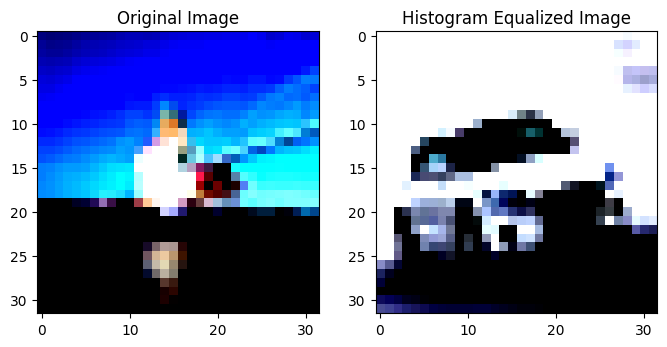

In [59]:
# Visualize original vs enhanced images
def visualize_histogram_equalization():
    original_img, _ = train_dataset[95]  # Get an image from the original dataset
    enhanced_img, _ = enhanced_train_dataset[95]  # Get the same image from the enhanced dataset

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(original_img.permute(1, 2, 0).numpy())
    ax[0].set_title("Original Image")
    ax[1].imshow(enhanced_img.permute(1, 2, 0).numpy())
    ax[1].set_title("Histogram Equalized Image")
    plt.show()

visualize_histogram_equalization()

<h1 style="color:red;">combined transformations 0.2</h1>

In [79]:
def visualize():
    # Get images from datasets
    original_img, _ = train_dataset[25]  # Get an image from the original dataset
    enhanced_img, _ = enhanced_train_dataset[25]  # Get the same image from the enhanced dataset

    # Resize the images for better visualization
    original_img_resized = resize(original_img, [128, 128])  # Resize to 128x128
    enhanced_img_resized = resize(enhanced_img, [128, 128])  # Resize to 128x128

    # Convert images back to NumPy for plotting
    original_img_np = original_img_resized.permute(1, 2, 0).numpy()
    enhanced_img_np = enhanced_img_resized.permute(1, 2, 0).numpy()

    # Plot the images side-by-side
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(original_img_np)
    ax[0].set_title("Original Image (Resized)")
    ax[0].axis('off')
    ax[1].imshow(enhanced_img_np)
    ax[1].set_title("Enhanced Image (Resized)")
    ax[1].axis('off')
    plt.show()

In [81]:
# Define combined transformations
transform_combined = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),  # Randomly flip the image horizontally
    transforms.RandomRotation(15),  # Randomly rotate by up to 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Adjust colors
    transforms.RandomCrop(32, padding=4),  # Randomly crop with padding
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=mean, std=std)  # Normalize using calculated mean and std
])

# Load datasets with the combined transformations
enhanced_train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform_combined)
enhanced_train_dataset, enhanced_validation_dataset = random_split(enhanced_train_dataset, [train_size, val_size])
enhanced_test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transform_combined)

# Create DataLoaders
enhanced_train_loader = DataLoader(enhanced_train_dataset, batch_size=batch_size, shuffle=True)
enhanced_validation_loader = DataLoader(enhanced_validation_dataset, batch_size=batch_size, shuffle=False)
enhanced_test_loader = DataLoader(enhanced_test_dataset, batch_size=batch_size, shuffle=False)

print("Data Loaders with combined transformations are ready.")


Files already downloaded and verified
Files already downloaded and verified
Data Loaders with combined transformations are ready.


In [82]:
#transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
model = CustomCNN()
criterion = nn.CrossEntropyLoss()  # CrossEntropyLoss for classification
optimizer = optim.Adam(model.parameters(), lr) # Adam optimizer with specified learning rate
train_model(model, enhanced_train_loader, enhanced_validation_loader, criterion, optimizer, epochs)
test_model(model, enhanced_test_loader)

Epoch [1/10], Training Loss: 1.6884, Validation Loss: 1.4389, Validation Accuracy: 48.06%
Epoch [2/10], Training Loss: 1.3420, Validation Loss: 1.2340, Validation Accuracy: 56.48%
Epoch [3/10], Training Loss: 1.1506, Validation Loss: 1.0811, Validation Accuracy: 61.58%
Epoch [4/10], Training Loss: 1.0377, Validation Loss: 0.9851, Validation Accuracy: 65.59%
Epoch [5/10], Training Loss: 0.9668, Validation Loss: 0.9548, Validation Accuracy: 66.13%
Epoch [6/10], Training Loss: 0.9111, Validation Loss: 0.9025, Validation Accuracy: 68.58%
Epoch [7/10], Training Loss: 0.8703, Validation Loss: 0.8837, Validation Accuracy: 69.42%
Epoch [8/10], Training Loss: 0.8404, Validation Loss: 0.8767, Validation Accuracy: 68.99%
Epoch [9/10], Training Loss: 0.8052, Validation Loss: 0.8791, Validation Accuracy: 69.43%
Epoch [10/10], Training Loss: 0.7869, Validation Loss: 0.8240, Validation Accuracy: 71.54%
Test Accuracy: 71.93%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2803516..2.755399].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4312234..0.45059294].


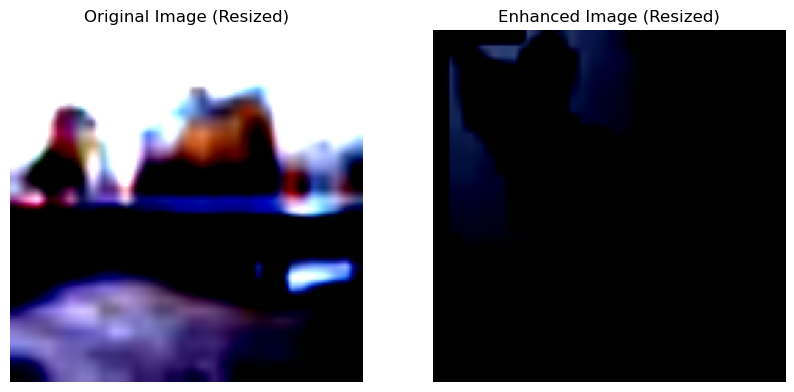

In [56]:
#transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
visualize()

<h1 style="color:red;">combined transformations 0.5</h1>

In [37]:
# Define combined transformations
transform_combined = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),  # Randomly flip the image horizontally
    transforms.RandomRotation(15),  # Randomly rotate by up to 15 degrees
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.1),  # Adjust colors
    transforms.RandomCrop(32, padding=4),  # Randomly crop with padding
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=mean, std=std)  # Normalize using calculated mean and std
])

# Load datasets with the combined transformations
enhanced_train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform_combined)
enhanced_train_dataset, enhanced_validation_dataset = random_split(enhanced_train_dataset, [train_size, val_size])
enhanced_test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transform_combined)

# Create DataLoaders
enhanced_train_loader = DataLoader(enhanced_train_dataset, batch_size=batch_size, shuffle=True)
enhanced_validation_loader = DataLoader(enhanced_validation_dataset, batch_size=batch_size, shuffle=False)
enhanced_test_loader = DataLoader(enhanced_test_dataset, batch_size=batch_size, shuffle=False)

print("Data Loaders with combined transformations are ready.")


Files already downloaded and verified
Files already downloaded and verified
Data Loaders with combined transformations are ready.


In [38]:
#transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.1)
model = CustomCNN()
criterion = nn.CrossEntropyLoss()  # CrossEntropyLoss for classification
optimizer = optim.Adam(model.parameters(), lr) # Adam optimizer with specified learning rate
train_model(model, enhanced_train_loader, enhanced_validation_loader, criterion, optimizer, epochs)
test_model(model, enhanced_test_loader)

Epoch [1/10], Training Loss: 1.7439, Validation Loss: 1.5274, Validation Accuracy: 44.24%
Epoch [2/10], Training Loss: 1.4097, Validation Loss: 1.2835, Validation Accuracy: 53.27%
Epoch [3/10], Training Loss: 1.2204, Validation Loss: 1.1453, Validation Accuracy: 58.89%
Epoch [4/10], Training Loss: 1.1086, Validation Loss: 1.0966, Validation Accuracy: 61.22%
Epoch [5/10], Training Loss: 1.0215, Validation Loss: 1.0102, Validation Accuracy: 64.04%
Epoch [6/10], Training Loss: 0.9616, Validation Loss: 0.9586, Validation Accuracy: 66.68%
Epoch [7/10], Training Loss: 0.9290, Validation Loss: 0.9337, Validation Accuracy: 67.11%
Epoch [8/10], Training Loss: 0.8892, Validation Loss: 0.9220, Validation Accuracy: 67.97%
Epoch [9/10], Training Loss: 0.8632, Validation Loss: 0.8822, Validation Accuracy: 69.47%
Epoch [10/10], Training Loss: 0.8387, Validation Loss: 0.8516, Validation Accuracy: 70.23%
Test Accuracy: 69.29%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7138251..2.1058354].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4312234..2.183392].


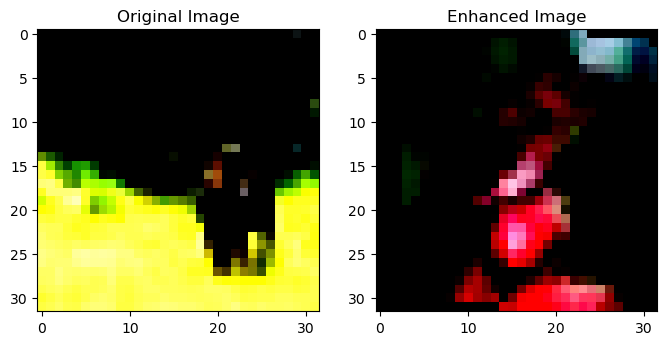

In [48]:
#transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.1)
visualize()